In [1]:
from ximea import xiapi
from workers.camera import XimeaCamera, CameraConfig, CameraMode, RoiDefinition
import time

In [2]:
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

In [3]:
config = CameraConfig(
    serial_number = None,
    mode = CameraMode.FULL_FRAME,
    exposure_us = 1000,
    frame_rate_hz = 100,
    rois = None,
    output_bit_depth = 12,
    transport_buffer_size = 8
)


In [11]:
single_roi = RoiDefinition(
    height = 512,
    width = 512,
    offset_x = 1992,
    offset_y = 1992,
    label = "single-roi",
    is_data = True
)

config = CameraConfig(
    serial_number = None,
    mode = CameraMode.SINGLE_ROI,
    exposure_us = 1000,
    frame_rate_hz = 200,
    rois = [single_roi],
    output_bit_depth = 12,
    transport_buffer_size = 8
)

In [12]:
times = []
with XimeaCamera(config) as cam:
    for _ in range(100):
        frame = cam.acquire_frame()
        print(frame.frame_id, frame.timestamp_ns, frame.host_time, frame.mode, frame.rois, frame.nframes_dropped)
        times.append(frame.timestamp_ns)

xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----
xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:680 OneBuff:385 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.


1 30773628554000 36555.735356089 CameraMode.SINGLE_ROI {'single_roi': array([[32, 32, 33, ..., 32, 31, 33],
       [33, 33, 32, ..., 31, 32, 31],
       [31, 31, 31, ..., 32, 32, 32],
       ...,
       [31, 32, 31, ..., 30, 32, 32],
       [32, 32, 32, ..., 32, 30, 33],
       [32, 33, 33, ..., 32, 32, 33]], dtype=uint16)} 0
2 30773633647000 36555.739610218 CameraMode.SINGLE_ROI {'single_roi': array([[31, 31, 33, ..., 31, 31, 31],
       [33, 32, 32, ..., 33, 30, 34],
       [32, 33, 32, ..., 32, 32, 32],
       ...,
       [32, 32, 31, ..., 33, 33, 31],
       [32, 32, 31, ..., 33, 31, 33],
       [32, 33, 32, ..., 31, 31, 32]], dtype=uint16)} 0
3 30773638739000 36555.747085848 CameraMode.SINGLE_ROI {'single_roi': array([[31, 32, 34, ..., 30, 32, 30],
       [33, 32, 33, ..., 32, 32, 32],
       [32, 31, 32, ..., 31, 32, 31],
       ...,
       [33, 32, 31, ..., 32, 33, 30],
       [33, 31, 32, ..., 30, 31, 32],
       [32, 31, 32, ..., 31, 31, 31]], dtype=uint16)} 0
4 30773643831000

xiAPI: xiCloseDevice


In [13]:
1/(np.mean(np.asarray(times)[1:]-np.asarray(times)[:-1])/1e9)

196.38025565138733

In [7]:
def get_camera_basic_info(cam: xiapi.Camera) -> str:
    """
    The function returns basic information about the camera and API version.
    
    :return device name, serial number, sensor serial number, api version:
    """
    if cam.is_isexist:
        name = cam.get_device_name().decode("UTF-8")
        sn = cam.get_device_sn().decode("UTF-8")
        try:
            sensor_sn = cam.get_device_sens_sn().decode("UTF-8")
        except Exception as e:
            sensor_sn = e
        api_version = cam.get_api_version().decode("UTF-8")

        return f"""
        Device Name:\t\t\t{name}
        Serial Number:\t\t\t{sn}
        Sensor Serial Number:\t\t{sensor_sn}
        Api Version:\t\t\t{api_version}
        """

In [4]:
cam = xiapi.Camera()

In [5]:
cam.open_device()

xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----


In [6]:
print(get_camera_basic_info(cam))


        Device Name:			MC203MG-SY-UB
        Serial Number:			CENAU2612001
        Sensor Serial Number:		CENAU2612001
        Api Version:			V4.32.00.00
        


In [7]:
cam.get_height()

4512

In [8]:
cam.get_height_increment()

8

In [9]:
cam.get_offsetY()

0

In [10]:
cam.get_offsetX()

0

In [11]:
cam.get_width()

4512

In [12]:
cam.get_width_increment()

8

In [13]:
time.monotonic()

9714.898785743

In [14]:
time.monotonic()

9720.931913631

In [9]:
cam.set_imgdataformat('XI_MONO16')

cam.set_exposure(200000)

img = xiapi.Image()

cam.start_acquisition()

cam.get_image(img)

data = img.get_image_data_numpy()

cam.stop_acquisition()

cam.close_device()

xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:8 OneBuff:29823 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.
xiAPI: xiCloseDevice


In [16]:
cam.open_device
get_camera_basic_info(cam)

xiAPI: GetFApiDeviceFromHandle - invalid magic x20202020
xiAPI: xiAPI error: Expected XI_OK in:../API/xiFAPI/interfaces/01_top/xifapi_Top.cpp xiGetParam/Line:371


Xi_error: ERROR 1: Invalid handle

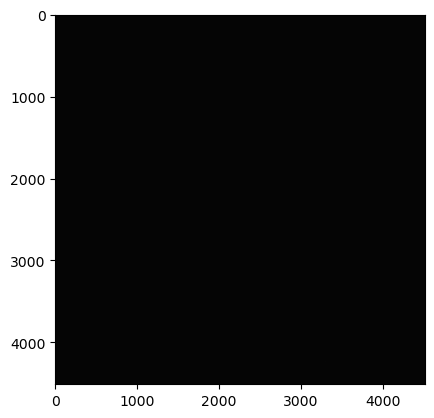

In [10]:
plt.imshow(data, cmap='gray');